In [2]:
import pandas as pd

df = pd.read_csv('workspot_dataset.csv')
print(df.head())
print(df.info())
print(df.shape)

   Age  Gender  Working_Hours  Commute_Time  Distance_from_Home  \
0   24    Male              9             5                   7   
1   20    Male             10            15                  15   
2   27  Female              7            13                   5   
3   29  Female             10            19                   4   
4   25  Female              7            14                  12   

   Work_Experience  Department  Work_Life_Balance_Score Preferred_Workplace  
0                5          HR                        8              Office  
1                5          HR                        7              Office  
2                5     Finance                        6              Office  
3                4  Operations                        8              Office  
4                4     Finance                        7              Office  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             

In [3]:
print(df.info())

print(df.describe())

print(df['Preferred_Workplace'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Working_Hours            1000 non-null   int64 
 3   Commute_Time             1000 non-null   int64 
 4   Distance_from_Home       1000 non-null   int64 
 5   Work_Experience          1000 non-null   int64 
 6   Department               1000 non-null   object
 7   Work_Life_Balance_Score  1000 non-null   int64 
 8   Preferred_Workplace      1000 non-null   object
dtypes: int64(6), object(3)
memory usage: 70.4+ KB
None
              Age  Working_Hours  Commute_Time  Distance_from_Home  \
count  1000.00000    1000.000000   1000.000000         1000.000000   
mean     35.36500       8.346000     36.436000           18.853000   
std       9.53408       1.190673     25.675731

In [4]:
print(df[['Gender', 'Department']].head(10))

   Gender  Department
0    Male          HR
1    Male          HR
2  Female     Finance
3  Female  Operations
4  Female     Finance
5  Female     Finance
6    Male     Finance
7    Male     Finance
8  Female     Finance
9  Female     Finance


In [5]:
# Data Preprocessing
df.isnull().sum()

Age                        0
Gender                     0
Working_Hours              0
Commute_Time               0
Distance_from_Home         0
Work_Experience            0
Department                 0
Work_Life_Balance_Score    0
Preferred_Workplace        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_dept = LabelEncoder()
df['Department'] = le_dept.fit_transform(df['Department'])

le_target = LabelEncoder()
df['Preferred_Workplace'] = le_target.fit_transform(
    df['Preferred_Workplace']
)

In [9]:
# Feature Selection
# Input Features
X = df.drop('Preferred_Workplace', axis=1)

# Target Variable
y = df['Preferred_Workplace']

In [10]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

best_rf = grid.best_estimator_

In [13]:
# XGBoost Classifier
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    random_state=42
)

xgb.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [15]:
# Model Evaluation
# Comparing Models
# Accuracies
from sklearn.metrics import accuracy_score

rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

Random Forest Accuracy: 0.98
XGBoost Accuracy: 0.97


In [17]:
# Precision, Recall, F1-Score
from sklearn.metrics import classification_report

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("XGBoost")
print(classification_report(y_test, xgb_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       1.00      0.95      0.97        40
           2       0.95      1.00      0.98        40
           3       1.00      0.95      0.97        40
           4       1.00      1.00      1.00        40

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

XGBoost
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        40
           1       1.00      0.93      0.96        40
           2       0.91      1.00      0.95        40
           3       1.00      0.95      0.97        40
           4       1.00      1.00      1.00        40

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



In [18]:
# Confuusion Matrices
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))
print(confusion_matrix(y_test, xgb_pred))

[[40  0  0  0  0]
 [ 0 38  2  0  0]
 [ 0  0 40  0  0]
 [ 2  0  0 38  0]
 [ 0  0  0  0 40]]
[[39  0  1  0  0]
 [ 0 37  3  0  0]
 [ 0  0 40  0  0]
 [ 2  0  0 38  0]
 [ 0  0  0  0 40]]


In [19]:
# Cross Validation
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5
).mean()

xgb_cv = cross_val_score(
    xgb,
    X,
    y,
    cv=5
).mean()

print("RF CV Score:", rf_cv)
print("XGB CV Score:", xgb_cv)

RF CV Score: 0.9799999999999999
XGB CV Score: 0.974


In [20]:
# Training Time Comparison
import time

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
xgb.fit(X_train, y_train)
xgb_time = time.time() - start

print("RF Training Time:", rf_time)
print("XGB Training Time:", xgb_time)

RF Training Time: 0.16422486305236816
XGB Training Time: 0.28124451637268066


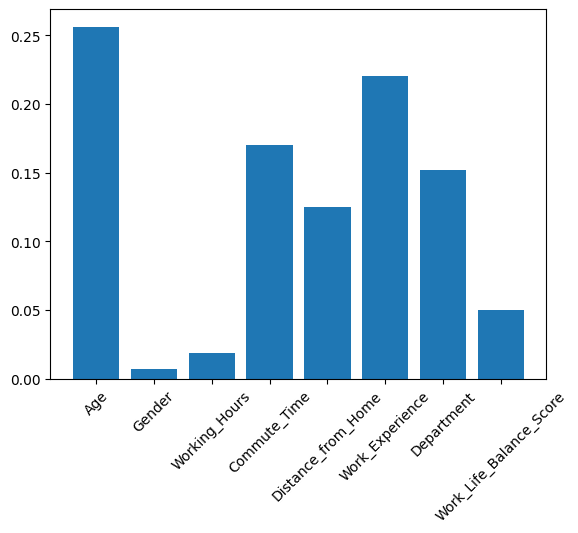

In [21]:
# Feature Importance
import matplotlib.pyplot as plt

importance = best_rf.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.show()

In [22]:
# Model Saving
import joblib

joblib.dump(best_rf,
            "workspot_model.pkl")

joblib.dump(le_gender, "gender_encoder.pkl")
joblib.dump(le_dept, "dept_encoder.pkl")
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [23]:

model = joblib.load("workspot_model.pkl")

sample = [[
    35,  # Age
    1,   # Gender (Male)
    8,   # Working Hours
    70,  # Commute Time
    40,  # Distance
    10,  # Experience
    4,   # Department (Sales)
    7    # WLB Score
]]

prediction = model.predict(sample)

print(le_target.inverse_transform(prediction))

['Remote']


c:\Users\jay10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Testing the saved model
model = joblib.load("workspot_model.pkl")

gender_encoder = joblib.load("gender_encoder.pkl")
dept_encoder = joblib.load("dept_encoder.pkl")
target_encoder = joblib.load("target_encoder.pkl")

In [26]:
age = int(input("Enter Age: "))
gender = input("Enter Gender (Male/Female): ")
working_hours = int(input("Enter Working Hours: "))
commute_time = int(input("Enter Commute Time (minutes): "))
distance = int(input("Enter Distance from Home (km): "))
experience = int(input("Enter Work Experience (years): "))
department = input("Enter Department: ")
wlb_score = int(input("Enter Work-Life Balance Score (1-10): "))

In [27]:
gender = gender_encoder.transform([gender])[0]
department = dept_encoder.transform([department])[0]

In [28]:
new_employee = pd.DataFrame([{
    "Age": age,
    "Gender": gender,
    "Working_Hours": working_hours,
    "Commute_Time": commute_time,
    "Distance_from_Home": distance,
    "Work_Experience": experience,
    "Department": department,
    "Work_Life_Balance_Score": wlb_score
}])

In [29]:
prediction = model.predict(new_employee)

result = target_encoder.inverse_transform(prediction)

print("\nPredicted Workplace:", result[0])


Predicted Workplace: Remote
